In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler #Estandariza los datos.
from sklearn.linear_model import LinearRegression #Importo el modelo.
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics

1. Linear regression for gallons. If the lienar regression in api-zonar-1 is different,the reason is that its model works in Liters. Dividing the slope and intercept with 3.785412 as divider, slope and intercept are very similar.

In [18]:


df_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Libro1_NO_SCALE.xlsx')
df_data.info()

df_data['NCode']=df_data['Measured']
df_data['Volume']=df_data['User']

#df_data.to_csv('/home/jlhb1984/py-projects/data/cases/Export.csv')

x=df_data['NCode'].values.reshape(-1, 1)#Si no se pone, sale error porque x_std y y_std requieren este reshape.
y=df_data['Volume'].values.reshape(-1, 1)
sc_x=StandardScaler()
sc_y=StandardScaler()
x_std=sc_x.fit_transform(x)
y_std=sc_y.fit_transform(y)
slr=LinearRegression()
slr.fit(x_std,y_std)

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   User         12 non-null     int64         
 1   Measured     12 non-null     int64         
 2   Date         12 non-null     datetime64[us]
 3   Temperature  12 non-null     int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 516.0 bytes


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
X_cols=df_data['NCode'].values.reshape(-1,1)
y_col=df_data['Volume'].values.reshape(-1,1)

X=X_cols
y=y_col

X_train, X_test, y_train, y_test = train_test_split(X,y)
sc_x=StandardScaler().fit(X)
sc_y=StandardScaler().fit(y)

X_train=sc_x.transform(X_train)
X_test=sc_x.transform(X_test)
y_train=sc_y.transform(y_train)
y_test=sc_y.transform(y_test)

model=LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [20]:
#print('X_train,y_train:\n',X_train,y_train,'\n','X_test,y_test:\n',X_train,y_test)

In [21]:
model = LinearRegression()
model.fit(X, y)

# 3. Access the Slope and Intercept
slope = model.coef_
intercept = model.intercept_

print(f"Slope (Coefficient): {slope}")
print(f"Intercept: {intercept}")

Slope (Coefficient): [[0.00831498]]
Intercept: [-0.95660724]


Text(0.5, 0, 'N code')

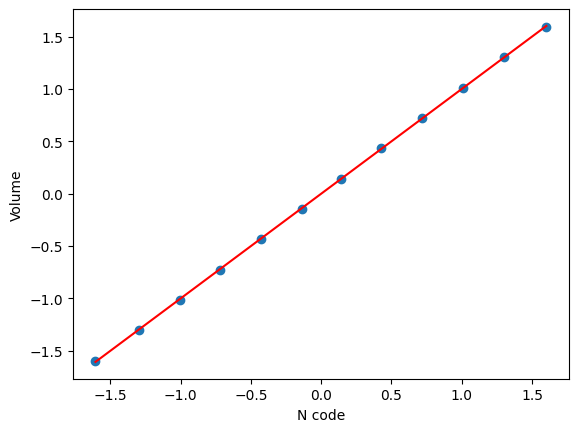

In [22]:
plt.scatter(x_std,y_std)
plt.plot(x_std,slr.predict(x_std),color='red')
plt.ylabel('Volume')
plt.xlabel('N code')

In [23]:
mse = metrics.mean_squared_error(y_test,y_pred)
r2 = metrics.r2_score(y_test, y_pred)

#print("r2 ", r2.round(4))
#print("mse: ", mse.round(4))
print("r2 ", r2)
print("mse: ", mse)

r2  0.999933064333979
mse:  4.8680484378926374e-05


In [24]:
ncode=input("N Code: ")
num_galons_lr=sc_x.transform(np.array([ncode]).reshape(-1,1))
sc_y.inverse_transform(slr.predict(num_galons_lr))

array([[-0.93997728]])